# 03 — Elastic Net Selection

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

## Purpose

This notebook implements Part I of the thesis: **real-time indicator selection from a high-dimensional macroeconomic panel**. The core methodology is an expanding-window Elastic Net regression with cross-validated regularisation, complemented by a fixed-*k* Bai & Ng (2008) benchmark for comparison. All procedures respect real-time data constraints to ensure that selections at each forecast origin use only information available at that point in time.

## Research Context

Modern macroeconomic nowcasting faces a fundamental trade-off: larger predictor sets offer richer information but introduce estimation noise, multicollinearity, and computational challenges (Bai & Ng, 2008; Stock & Watson, 2012). Indicator selection methods aim to identify a parsimonious subset of predictors that retain the signal while discarding redundant or noisy series. This notebook addresses the selection problem; `06_dfm_nowcasting.ipynb` uses the selected sets as inputs to a Dynamic Factor Model for GDP growth nowcasts.

**Key design choices:**
1. **Elastic Net regularisation:** Combines ℓ₁ (Lasso sparsity) and ℓ₂ (Ridge stability) penalties, well-suited for correlated macro panels (Zou & Hastie, 2005; De Mol et al., 2008).
2. **Quarterly target frequency:** GDP is observed quarterly; monthly predictors are temporally aggregated to align with the target (see aggregation rules below).
3. **Expanding window:** Training sample grows month-by-month to mimic real-time forecaster decision-making; no look-ahead bias.
4. **COVID-19 adjustment:** Following Lenza & Primiceri (2022), pandemic quarters (2020Q2–2021Q1) are downweighted in the loss function to prevent extreme observations from dominating the regularisation path.

## Main Outputs

All results are saved under `outputs/indicator_selection/`:

| File | Content |
|---|---|
| `gdp_target.csv` | Quarterly real-time GDP growth series (QoQ log-difference, percentage points) extracted from the vintage matrix |
| `selection_matrix.csv` | Binary selection matrix (180 monthly origins × 585 series) for Elastic Net |
| `selection_results.json` | Per-origin metadata: selected series IDs, optimal hyperparameters (α, ℓ₁-ratio), CV error, training window boundaries |
| `selection_matrix_fixedk.csv` | Binary selection matrix for the fixed-*k* = 30 Bai–Ng benchmark |
| `selection_results_fixedk.json` | Per-origin diagnostics for the fixed-*k* procedure |

These outputs are consumed by `04_pls_selection_and_stability.ipynb` and `05_build_model_inputs.ipynb`.

## Methodological Details

### Temporal Design: Monthly Origins, Quarterly Training

**Forecast origins:** Monthly from 2011-01 to 2025-12 (180 points). Each origin represents the information cutoff for a pseudo-real-time nowcast.

**Training frequency:** The quarterly training-end date advances only at quarter boundaries. Consequently:
- All three monthly origins within a quarter (e.g., 2020-01, 2020-02, 2020-03) share the same training window terminating in 2019Q4.
- `ElasticNetCV` is refit at most once per quarter (~60 unique model fits over the 180 origins).
- This design reflects real-world practice: quarterly GDP is the target, so predictor selection updates when new quarterly information becomes available.

### Predictor Aggregation: Monthly → Quarterly (raw-level bridge)

Predictors are aggregated with an economically careful **raw-level → quarterly → re-transform** bridge (`german_gdp_nowcasting.selection.aggregation`).

1. **Start from raw levels** (`data/panel/data_df.csv`). At a nowcast origin, ragged within-quarter months are AR(p)-BIC filled on the transformed series and then **back-transformed** to raw levels (chained from the last observed level), so every month of the target quarter has a raw-level estimate.
2. **Aggregate raw monthly → quarterly level** as the **quarterly mean** of the three raw monthly levels (`AGGREGATION_RULES`, keyed by metadata `category`/`unit`/`trafo`). Raw index levels are never summed.
3. **Re-transform** the quarterly raw level into the stationary series the model uses:

| Transformation | Quarterly object | Count | Rationale |
|---|---|---|---|
| `trafo = 0` | **Identity** (quarterly mean level) | 398 series | Levels, rates, indices, surveys: the average within-quarter value is the quarterly state |
| `trafo ≠ 0` | **Δln of the quarterly average level** (×100) | 187 series | QoQ log-growth of the quarterly-average level — the object official quarterly statistics publish (fallback to simple diff for non-positive levels) |

**Example:**  
- Industrial production: average the three monthly raw index levels → quarterly level, then take Δln vs the previous quarterly level.
- IFO business climate (level): average three monthly values → quarterly index level (identity).

**Why not sum raw index levels?** Summing monthly index levels is not economically meaningful. For growth series, quarterly log-growth is taken on the **quarterly average level** — the object official statistics publish. Summing monthly log-differences would instead telescope to end-of-quarter log growth (`Σ Δln x_m ≡ ln x_{M3} − ln x_{M0}`), which is a different quantity. This temporal-aggregation logic is standard in mixed-frequency nowcasting (Bańbura et al., 2013; Giannone et al., 2008).

**Note:** The DFM in `06_dfm_nowcasting.ipynb` operates on the original **monthly** panel to exploit publication-lag patterns and within-quarter information arrival. The quarterly aggregation applies only to Part I (selection stage).

### Elastic Net Configuration

**Estimator:** `ElasticNetCV` from scikit-learn with time-series cross-validation (`TimeSeriesSplit`, 5 folds) to select optimal hyperparameters at each origin.

**Regularisation path:**  
- **α** (penalty strength): 20 log-spaced values from 0.001 to 1.0  
- **ℓ₁-ratio** (Lasso/Ridge mix): [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

Warm starts accelerate the path search. The optimal (α, ℓ₁-ratio) pair is chosen by minimising cross-validated mean squared error.

**Sample weighting (COVID-19):**  
Following Lenza & Primiceri (2022), quarters 2020Q2 through 2021Q1 are assigned weight 0.25 (vs. 1.0 for all other quarters) to prevent pandemic outliers from distorting coefficient estimates. This is implemented as row-level sample weights in `ElasticNetCV`.

### GDP Target Construction: Real-Time Vintage Handling

The GDP growth series is extracted from the real-time vintage matrix (`GDP_vintage.xlsx`) using the `extract_gdp_target` function. Key principle: **first-release vintage rule** (the earliest vintage in which a quarter appears) to mimic real-time constraints.

**Construction:**
1. For each calendar quarter *q*, find the leftmost (earliest) vintage column in the spreadsheet where *q* is non-missing.
2. Read both *q* and *q*−1 from that **same vintage column** to compute an internally consistent growth rate.
3. Compute QoQ log-difference: 100 × [log(GDP_q) − log(GDP_{q−1})].

**Important caveat:**  
If the vintage matrix only begins in (e.g.) 2005, earlier calendar quarters (1991–2004) are populated from the first column. These are **embedded back-history** in that vintage file, not literal "flash estimates" from the 1990s. For training-sample construction, this is acceptable (Croushore & Stark, 2001); for out-of-sample nowcast evaluation, one should ideally use vintages contemporaneous with each forecast origin (Giannone et al., 2008). The current design prioritises Part I (selection) over strict vintage alignment in early periods.

**Output:** A quarterly series of GDP growth rates used as the target variable *y* in Elastic Net training. See Section 1 printout for vintage availability diagnostics.

### Fixed-*k* Bai–Ng Benchmark

As a non-data-adaptive comparison, the notebook implements the Bai & Ng (2008) two-step procedure:

1. **Pre-screening:** Retain series with marginal correlation |corr(*x*, *y*)| above a *t*-statistic threshold (default: 1.65, one-sided 5% critical value).
2. **Path-based selection:** Traverse the Elastic-Net regularisation path (fixed ℓ₁-ratio) and stop at the first step with *k* = 30 active coefficients (not the IC₂ factor-count criterion — see §4 note).

This provides a fixed-dimension baseline unaffected by regularisation path noise. Comparison with Elastic Net (variable dimension, data-driven α) quantifies the value of adaptive selection.

## Enhanced Features (Pipeline V2)

This notebook incorporates four enhancements relative to a baseline Elastic Net:

| Feature | Status | Rationale |
|---|---|---|
| **Iterative imputation** |  (Optional: simple mean) | MICE-style imputation for ragged-edge missing data; slower but more accurate |
| **Marginal *t*-stat pre-filter** | Optional (default: ON) | Bai & Ng (2008) pre-screening to remove clearly uninformative series before regularisation |
| **Distributed lags** | Optional (default: OFF at quarterly freq) | Not used; relevant only if monthly target were constructed |
| **COVID sample weights** | ON | Downweight 2020Q2–2021Q1 per Lenza & Primiceri (2022) |

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Bańbura, M., Giannone, D., & Reichlin, L. (2013). Nowcasting. In M. P. Clements & D. F. Hendry (Eds.), *Oxford Handbook of Economic Forecasting* (pp. 193–224). Oxford University Press.
- Croushore, D., & Stark, T. (2001). A real-time data set for macroeconomists. *Journal of Econometrics*, 105(1), 111–130.
- De Mol, C., Giannone, D., & Reichlin, L. (2008). Forecasting using a large number of predictors: Is Bayesian shrinkage a valid alternative to principal components? *Journal of Econometrics*, 146(2), 318–328.
- Giannone, D., Reichlin, L., & Small, D. (2008). Nowcasting: The real-time informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4), 665–676.
- Lenza, M., & Primiceri, G. E. (2022). How to estimate a VAR after March 2020. *Journal of Applied Econometrics*, 37(4), 688–699.
- Stock, J. H., & Watson, M. W. (2012). Generalized shrinkage methods for forecasting using many predictors. *Journal of Business & Economic Statistics*, 30(4), 481–493.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B*, 67(2), 301–320.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.selection.core_utils import (
    DEFAULT_ALPHAS,
    DEFAULT_L1_RATIOS,
    build_coverage_mask,
    extract_gdp_target,
    load_monthly_panel,
    load_pub_lag_map,
    load_trafo_map,
    make_monthly_forecast_origins,
    monthly_to_quarterly,
    parse_gdp_realtime,
    save_selection_outputs,
)
from german_gdp_nowcasting.selection.elastic_net_selection import (
    covid_sample_weights,
    run_expanding_selection,
)

# New parameters for the enhanced pipeline (can be overridden below)
IMPUTER_STRATEGY = "iterative"   # "mean" (default, fast) | "iterative" (opt-in, ~30–45 min full run)
TSTAT_PREFILTER = True      # Bai & Ng (2008) marginal t-stat pre-screen
TSTAT_THRESHOLD = 1.65      # |t| threshold (one-sided 5%)
N_LAGS = 0                  # distributed lags per series (0 = off, correct default at quarterly freq)
# Lenza & Primiceri (2022): downweight COVID quarters inside ElasticNetCV (row-scaling in ts_elastic_net).
# EN_SAMPLE_WEIGHT is built in §2 after y_quarterly is loaded.
USE_COVID_SAMPLE_WEIGHT = True
COVID_WEIGHT_START = "2020Q2"
COVID_WEIGHT_END = "2021Q1"
COVID_WEIGHT_VALUE = 0.25
EN_SAMPLE_WEIGHT = None  # set in §2
DATA_PATH = _tp.DATASET_XLSX
X_PATH = _tp.PANEL_TRANSFORMED_CSV
DICT_PATH = _tp.DATA_DICT_ENRICHED_CSV
PUB_LAG_PATH = _tp.PUB_LAG_CSV
GDP_TARGET_PATH = _tp.GDP_TARGET_CSV
OUT_DIR = _tp.OUT_INDICATOR_SELECTION
# Elastic Net full expanding-window run (writes selection_matrix.csv + selection_results.json).
# If both files already exist under OUT_DIR, they are loaded and the expensive loop is skipped
# unless FORCE_RERUN_EN_SELECTION = True.
RUN_FULL_SELECTION = True
FORCE_RERUN_EN_SELECTION = False  # True → refit even when CSV/JSON already exist
# Block-balanced (k=20) Bai–Ng benchmark.
# If both exist, load and skip unless FORCE_RERUN_FIXEDK = True.
RUN_FIXEDK = True
FORCE_RERUN_FIXEDK = False  # True → refit even when fixed-k CSV/JSON already exist
FORECAST_START = '2011-01'
FORECAST_END = '2025-12'
MIN_COVERAGE = 0.30       # series must have ≥30% non-NaN in training window
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Forecast window: {FORECAST_START} → {FORECAST_END}')


## 1. Load and Validate Inputs

### Data Sources

This section loads three inputs produced by notebook `02_data_preparation.ipynb`:

1. **Transformed monthly panel** (`PANEL_TRANSFORMED_CSV`): 585 series in stationary form (levels, growth rates, or differences) covering 1991-01 through 2025-12.

2. **Enriched data dictionary** (`DATA_DICT_ENRICHED_CSV`): Metadata including transformation codes (`trafo`), publication lags, and economic categories for each series.

3. **GDP real-time vintage matrix** (`GDP_realtime` sheet in `DATASET_XLSX`): Quarterly GDP level data with vintage columns representing successive data releases.

### GDP Target Construction

The `extract_gdp_target` function constructs a quarterly GDP growth series from the vintage matrix using the **first-release vintage rule** (the earliest vintage in which each quarter appears):

- For each calendar quarter *q*, identify the leftmost vintage column where *q* is non-missing.
- Extract both *q* and *q*−1 from that same vintage to ensure internal consistency.
- Compute quarter-on-quarter log-growth: 100 × [log(GDP_q) − log(GDP_{q−1})].

**Diagnostic output:** The cell prints vintage matrix dimensions and demonstrates the extraction for a sample quarter (e.g., 1991Q2), showing which vintage column provides the data for that observation.

**Real-time caveat:** If the vintage matrix begins in (e.g.) 2005, pre-2005 quarters are populated from the first column's embedded back-history. These are not literal "flash estimates" from the 1990s but represent the earliest available series in the dataset (Croushore & Stark, 2001). For indicator selection (Part I), this is acceptable; strict vintage alignment matters more for out-of-sample forecast evaluation (Giannone et al., 2008).

**References:**
- Croushore, D., & Stark, T. (2001). A real-time data set for macroeconomists. *Journal of Econometrics*, 105(1), 111–130.
- Giannone, D., Reichlin, L., & Small, D. (2008). Nowcasting: The real-time informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4), 665–676.


In [ ]:
required_paths = [DATA_PATH, X_PATH, DICT_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Missing required input files: {missing_paths}')
X_monthly   = load_monthly_panel(X_PATH)
trafo_map   = load_trafo_map(DICT_PATH)
y_quarterly = extract_gdp_target(DATA_PATH)
pub_lag_map = load_pub_lag_map(PUB_LAG_PATH)
# Vintage-matrix span (ifoCAST): columns are publication dates. Growth for each
# quarter uses the leftmost column where that quarter is non-missing. If the
# sheet only lists vintages from (e.g.) 2005 onward, pre-2005 calendar quarters
# still have entries in column 0 — those are back-history levels as of that
# vintage, not the statistical office's original flash from the 1990s.
_gdp_raw = pd.read_excel(DATA_PATH, sheet_name='GDP_realtime', header=None)
_vintages = parse_gdp_realtime(_gdp_raw)
print(
    f'GDP vintage matrix      : {_vintages.shape[0]} quarters × {_vintages.shape[1]} vintages; '
    f'columns { _vintages.columns.min().date() } → { _vintages.columns.max().date() }'
)
_row91 = _vintages.loc['1991Q2']
_first_v91 = _row91[_row91.notna()].index[0]
print(
    f'Example 1991Q2          : first non-NaN column (used for growth) = {_first_v91.date()}'
)
y_quarterly.to_csv(GDP_TARGET_PATH, header=True)
print(f'Monthly predictor panel : {X_monthly.shape[0]} months × {X_monthly.shape[1]} series')
print(f'Predictor range         : {X_monthly.index.min().date()} → {X_monthly.index.max().date()}')
print(f'GDP target              : {len(y_quarterly)} quarters')
print(f'GDP target range        : {y_quarterly.index.min()} → {y_quarterly.index.max()}')
print(f'GDP target saved        : {GDP_TARGET_PATH}')
print(f'Publication lag map     : {len(pub_lag_map)} series  |  lag range {int(pub_lag_map.min())}–{int(pub_lag_map.max())} months')
if set(X_monthly.columns) != set(trafo_map.index):
    raise ValueError('Predictor columns and data dictionary ids are not identical.')
missing_share = X_monthly.isna().mean().describe(percentiles=[0.1, 0.5, 0.9])
print('\nMissing-share distribution across monthly predictors:')
print(missing_share.round(3))


## 2. Aggregate Predictors to Quarterly Frequency and Build Coverage Mask

### Temporal Aggregation: Monthly → Quarterly (raw-level bridge)

The Elastic Net operates on quarterly data to match the GDP target frequency. Aggregation follows an economically-careful **raw-level → quarterly → re-transform** bridge (central `aggregation` module):

| Step | Rule | Economic Rationale |
|---|---|---|
| 1. Raw → quarterly **level** | Quarterly **mean** of the three raw monthly levels (`AGGREGATION_RULES`, every category) | Quarterly average is the standard temporal aggregation of within-quarter flows (orders, turnover, production, trade), prices/commodities (average quarterly price), and level-stationary surveys/rates. Raw index levels are **never summed**. |
| 2. Re-transform | `trafo_applied = 0` → **identity** (level kept); `trafo_applied ≠ 0` → quarterly **Δln** (log-growth of the quarterly level), simple-difference fallback for non-positive levels | Reproduces the offline transform's quarterly analogue, yielding the published-style quarterly growth rate. |

For growth series, `Δln(mean(raw monthly levels))` is the quarterly-average log-growth rate that official statistics report (not end-of-quarter telescoped growth from summing monthly log-differences). Level-stationary series (`trafo_applied = 0`) remain the within-quarter average level.

**Implementation:** The `monthly_to_quarterly` function (in `core_utils`) delegates to `aggregation.monthly_to_quarterly_raw`, loading the raw panel internally. While computed once here for inspection, `run_expanding_selection` recomputes it internally at each origin to ensure strict real-time data boundaries.

**Important:** This quarterly aggregation applies *only* to Part I (indicator selection). The Dynamic Factor Model in `06_dfm_nowcasting.ipynb` operates on the original **monthly** panel to exploit publication-lag patterns and within-quarter information arrival (Bańbura & Rünstler, 2011).

### Coverage Mask: Data Availability Filter

**Purpose:** Exclude series with insufficient historical coverage at each forecast origin to prevent selection of sparsely observed predictors.

**Construction:** For each series and each monthly origin *t*, `build_coverage_mask` computes the proportion of non-missing **monthly** observations from 1991-01 through the last month of *t*'s training window. Series with coverage ≥ `MIN_COVERAGE` (default: 30%) are retained; others are masked out.

**Empirical result:** With the current panel:
- At the first origin (2011-01): 567 of 585 series pass the 30% threshold.
- By the final origin (2025-12): All 585 series pass (coverage improves as the evaluation window advances relative to the fixed 1991 start).
- The filter primarily removes series with very late start dates or extended missing periods in the early sample.

### Residual Missing Data Handling

After quarterly aggregation and coverage filtering, some series retain isolated NaN quarters (e.g., series beginning mid-sample). The Elastic Net pipeline handles these through:

1. **Imputation:** `IterativeImputer` (MICE-style, default) or `SimpleImputer(strategy='mean')` depending on `IMPUTER_STRATEGY` setting. Fitted on training data only to prevent look-ahead bias.

2. **Standardisation:** `StandardScaler` centers and scales predictors post-imputation. Imputed values become zeros after scaling and are naturally downweighted by regularisation.

**Pipeline note:** Imputation and scaling are performed *once per training window* outside the cross-validation loop, then `ElasticNetCV` searches the regularisation path via warm starts — substantially faster than repeated imputation inside CV folds.

**References:**
- Bańbura, M., & Rünstler, G. (2011). A look into the factor model black box: Publication lags and the role of hard and soft data in forecasting GDP. *International Journal of Forecasting*, 27(2), 333–346.


In [3]:
forecast_origins = make_monthly_forecast_origins(FORECAST_START, FORECAST_END)
X_quarterly = monthly_to_quarterly(X_monthly, trafo_map)
coverage_mask = build_coverage_mask(
    X_monthly,
    forecast_origins,
    min_coverage=MIN_COVERAGE,
)
# series_per_origin[t] = number of series that pass the coverage filter at origin t
series_per_origin = coverage_mask.sum(axis=1)
_n_origins = len(forecast_origins)
print(f'Forecast origins     : {forecast_origins[0]} → {forecast_origins[-1]}  ({_n_origins} monthly origins)')
print(f'Quarterly predictors : {X_quarterly.shape[0]} quarters × {X_quarterly.shape[1]} series')
print()
print(f'Coverage filter (≥{MIN_COVERAGE:.0%} non-NaN observations in training window):')
print(f'  Eligible series at first origin ({forecast_origins[ 0]}) : {series_per_origin.iloc[ 0]} / {X_monthly.shape[1]}')
print(f'  Eligible series at last  origin ({forecast_origins[-1]}) : {series_per_origin.iloc[-1]} / {X_monthly.shape[1]}')
print(f'  Min across all {_n_origins} origins : {series_per_origin.min()}   Max : {series_per_origin.max()}')
print()
print('Residual NaN handling: IterativeImputer (default) or SimpleImputer(mean) inside the Elastic Net pipeline')
print('fills any remaining NaN quarters with the column training mean before fitting.')
# Elastic Net CV observation weights (Lenza & Primiceri 2022) — passed to run_expanding_selection
if USE_COVID_SAMPLE_WEIGHT:
    EN_SAMPLE_WEIGHT = covid_sample_weights(
        y_quarterly,
        start=COVID_WEIGHT_START,
        end=COVID_WEIGHT_END,
        weight=COVID_WEIGHT_VALUE,
    )
    _n_down = int((EN_SAMPLE_WEIGHT < 1.0).sum())
    print()
    print('Elastic Net sample_weight (COVID downweight):')
    print(f'  Quarters {COVID_WEIGHT_START}–{COVID_WEIGHT_END}: weight = {COVID_WEIGHT_VALUE}; else 1.0')
    print(f'  Quarters with w < 1: {_n_down}  |  min weight = {EN_SAMPLE_WEIGHT.min():.3f}')
else:
    EN_SAMPLE_WEIGHT = None
    print()
    print('Elastic Net sample_weight: None (uniform weights in CV)')

Forecast origins     : 2011-01 → 2025-12  (180 monthly origins)
Quarterly predictors : 140 quarters × 585 series

Coverage filter (≥30% non-NaN observations in training window):
  Eligible series at first origin (2011-01) : 567 / 585
  Eligible series at last  origin (2025-12) : 585 / 585
  Min across all 180 origins : 567   Max : 585

Residual NaN handling: IterativeImputer (default) or SimpleImputer(mean) inside the Elastic Net pipeline
fills any remaining NaN quarters with the column training mean before fitting.

Elastic Net sample_weight (COVID downweight):
  Quarters 2020Q2–2021Q1: weight = 0.25; else 1.0
  Quarters with w < 1: 4  |  min weight = 0.250


## 3. Lightweight Smoke Test (Optional Validation)

### Purpose

Before running the full 180-origin expanding-window procedure (~60 Elastic Net fits, 20–40 minutes), this optional smoke test validates the pipeline on the first three monthly origins (2011-01, 2011-02, 2011-03) using identical hyperparameter settings.

### Design

**Origins tested:** The first three months (all falling in 2011Q1) share the same training window (ending in 2010Q4). The quarterly cache logic ensures:
- Origin 2011-01: Triggers a new `ElasticNetCV` fit.
- Origins 2011-02, 2011-03: Reuse the cached selection from 2011-01 (identical training data).

**Expected runtime:**  
- With `IMPUTER_STRATEGY = "mean"` and `N_LAGS = 0`: 5–15 seconds (one CV fit with warm-started regularisation path).
- With `IMPUTER_STRATEGY = "iterative"`: 30–60 seconds (iterative imputation adds overhead).

**Validation checks:**
1. Pipeline executes without errors.
2. Selection matrix dimensions match expectations (3 origins × 585 series).
3. Origins 2011-02 and 2011-03 produce identical selections (quarterly cache).
4. No convergence warnings (quarterly aggregation has low residual missingness).

**When to use:** Run the smoke test after modifying `core_utils.py`, `elastic_net_selection.py`, or changing hyperparameter grids to verify correctness before committing to the full run.

**To skip:** Set `SMOKE_TEST = False` in the setup cell and proceed directly to Section 4.


In [ ]:
SMOKE_TEST = False
import os
if SMOKE_TEST:
    # First 3 monthly origins share the same training window (training end = 2010Q4)
    # so the Elastic Net is fitted once and cached for origins 2 and 3.
    smoke_origins = forecast_origins[:3]
    smoke_mask = coverage_mask.loc[[str(o) for o in smoke_origins]]
    os.environ["THESIS_GRID_NJOBS"] = "3"
    # Match Section 3 (full run): same CV depth and hyperparameter grids. A
    # smaller n_splits / narrower l1_ratio / shorter alpha range skews CV
    # toward very sparse LASSO solutions and is not representative.
    smoke_matrix, smoke_results = run_expanding_selection(
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        trafo_map=trafo_map,
        forecast_origins=smoke_origins,
        coverage_mask=smoke_mask,
        train_start_quarter='1991Q1',
        min_selected=1,
        n_splits=5,
        l1_ratios=DEFAULT_L1_RATIOS,
        alphas=DEFAULT_ALPHAS,
        imputer_strategy=IMPUTER_STRATEGY,
        tstat_prefilter=TSTAT_PREFILTER,
        tstat_threshold=TSTAT_THRESHOLD,
        n_lags=N_LAGS,
        sample_weight=EN_SAMPLE_WEIGHT,
    )
    # Use the first origin for the detailed report (others are identical — cached)
    origin_key = str(smoke_origins[0])
    res = smoke_results[origin_key]
    # Null-model benchmark: MSE of predicting the training mean for every quarter
    train_end = pd.Period(res['train_end'], freq='Q')
    y_train = y_quarterly.loc[
        pd.Period('1991Q1', freq='Q'):train_end
    ].dropna()
    null_mse = float(y_train.var())
    r2_cv = 1.0 - res['cv_mse'] / null_mse
    print(f"=== Smoke-test origin: {origin_key} ===")
    print(f"  Training window : {res['train_start']} → {res['train_end']}  ({res['n_train_quarters']} quarters)")
    print(
        f"  Candidates      : {res['n_candidate_variables']} / {X_monthly.shape[1]} "
        "series (≥30% monthly coverage)"
    )
    print(f"  Selected        : {res['n_selected_variables']} indicators")
    print(f"  Best alpha      : {res['alpha']:.4f}   l1_ratio: {res['l1_ratio']}")
    print()
    print(f"  CV MSE (Elastic Net)  : {res['cv_mse']:.4f} pp²    RMSE: {res['cv_mse']**0.5:.4f} pp")
    print(f"  Null model MSE (mean) : {null_mse:.4f} pp²    Std(y): {null_mse**0.5:.4f} pp")
    print(
        f"  Approx R²_cv          : {r2_cv:.3f}  "
        f"(1 − CV MSE / Var(y) over full training window; not a foldwise OOS R²)"
    )
    print()
    print(f"  All {res['n_selected_variables']} selected indicators:")
    for var in res['selected_variables']:
        print(f"    {var}")
    print()
    print(f"  Cache check: origins 2011-02 and 2011-03 reuse the same fit:")
    for ok in [str(o) for o in smoke_origins]:
        n = smoke_results[ok]['n_selected_variables']
        end = smoke_results[ok]['train_end']
        print(f"    {ok}  →  train_end={end}  n_selected={n}")
    assert smoke_matrix.shape == (3, X_monthly.shape[1]), "Unexpected selection matrix shape."
    assert smoke_matrix.values.min() >= 0 and smoke_matrix.values.max() <= 1, "Values must be 0/1."
    print()
    print('Smoke test passed.')
else:
    print('Smoke test skipped.')


## 4. Expanding-Window Elastic Net Selection (Main Procedure)

### Overview

This section implements the core indicator selection procedure: an expanding-window Elastic Net regression with cross-validated regularisation, applied to 180 monthly forecast origins (2011-01 through 2025-12). The output is a binary selection matrix indicating which predictors are retained at each origin.

### Temporal Efficiency: Quarterly Cache

**Key optimisation:** While 180 monthly origins are processed, the underlying **quarterly** training window changes only at quarter boundaries. Consequently:

- **First month of each quarter** (e.g., 2020-01, 2020-04, 2020-07, 2020-10): Trigger a new `ElasticNetCV` fit.
- **Second and third months** (e.g., 2020-02, 2020-03): Reuse the cached selection and hyperparameters from the first month.

**Practical impact:** The procedure performs approximately **60 unique CV fits** (one per quarter from 2011Q1 to 2025Q4), not 180. This reflects real-world nowcasting practice: quarterly GDP is the target, so predictor selection updates when new quarterly information arrives.

**Implementation:** The `run_expanding_selection` function tracks `train_end` (quarter) and reuses results when consecutive origins have identical training windows.

### Cross-Validation Configuration

**Splitter:** `TimeSeriesSplit(n_splits=5)` respects temporal ordering within the training sample. Each fold uses earlier data for training and later data for validation.

**Hyperparameter grid:**
- **α** (penalty strength): 40 log-spaced values from 0.001 to 10.0 (defined in `DEFAULT_ALPHAS`)
- **ℓ₁-ratio** (Lasso/Ridge mix): (0.1, 0.5, 0.9, 1.0) — four values (defined in `DEFAULT_L1_RATIOS`)

The optimal (α, ℓ₁-ratio) pair minimises mean squared error across CV folds. Warm starts accelerate the path search by reusing coefficient estimates from previous α values.

**Selection criterion:** A predictor is selected if its coefficient is non-zero at the optimal hyperparameters.

### COVID-19 Sample Weighting

**Motivation:** Pandemic quarters (2020Q2–2021Q1) exhibit extreme GDP volatility unrepresentative of typical business-cycle dynamics. Without adjustment, these outliers can dominate regularisation path selection (Lenza & Primiceri, 2022).

**Implementation:** When `USE_COVID_SAMPLE_WEIGHT = True` (default), quarters in the range [`COVID_WEIGHT_START`, `COVID_WEIGHT_END`] receive sample weight 0.25 (vs. 1.0 for all other quarters). This downweighting is applied by scaling training observations by √*w* before `ElasticNetCV.fit`.

**Effect:** The regularisation path emphasises pre- and post-pandemic relationships, treating the 2020 shock as a temporary outlier rather than a structural regime shift. This is consistent with nowcasting practice post-2020 (Angelini et al., 2022; Delle Monache et al., 2021).

**To disable:** Set `USE_COVID_SAMPLE_WEIGHT = False` to reproduce the unweighted baseline.

### Enhanced Pipeline Features

The current implementation includes four optional enhancements controlled by setup-cell parameters:

| Feature | Default | Purpose | Trade-off |
|---|---|---|---|
| **Iterative imputation** | OFF (`"mean"`) | MICE-style imputation for ragged-edge data | Slower (~30–45 min) but more accurate for series with complex missing patterns |
| **Marginal *t*-stat pre-filter** | ON | Bai & Ng (2008) pre-screening: retain only series with |*t*| > `TSTAT_THRESHOLD` (1.65) before EN | Reduces EN input dimension, may improve stability |
| **Distributed lags** | OFF (`N_LAGS = 0`) | Add lagged predictors | Not recommended at quarterly frequency; temporal structure handled by DFM |
| **COVID sample weights** | ON | Downweight pandemic quarters | Essential for post-2020 robustness |

**Recommendation:** The default configuration (`"mean"` imputation, *t*-stat filter ON, lags OFF, COVID weights ON) balances speed and robustness. Use `"iterative"` imputation only for final runs or sensitivity checks.

### Publication-Lag Handling

**Important:** The Elastic Net selection operates on the **full historical training sample** without publication-lag constraints. Real-time data availability (unbalanced panel, ragged edge) is handled by the Dynamic Factor Model in `06_dfm_nowcasting.ipynb`, which respects within-quarter release calendars.

**Rationale:** The EN's role is to identify predictors with historical GDP predictive power. The DFM then weights these predictors by their real-time availability at each nowcast origin. This two-stage design (selection on full history → real-time DFM estimation) is standard in mixed-frequency nowcasting (Giannone et al., 2008; Bańbura et al., 2013).

### Output Management

**Primary outputs:**
- `selection_matrix.csv`: Binary matrix (180 × 585) with entry (*t*, *j*) = 1 if series *j* is selected at origin *t*.
- `selection_results.json`: Per-origin metadata including selected series IDs, optimal (α, ℓ₁-ratio), CV MSE, and training window boundaries.

**File handling:**
- Set `FORCE_RERUN_EN_SELECTION = True` in the setup cell to force a fresh run even if outputs exist.
- Set `RUN_FULL_SELECTION = False` to raise an error if outputs are missing (prevents accidental reruns during exploratory work).

**Expected runtime:**  
- Default configuration (`"mean"` imputation): 15–25 minutes (60 CV fits with 5 folds each).
- `"iterative"` imputation: 30–45 minutes (iterative imputation adds ~20 seconds per fit).

**References:**
- Angelini, E., Bacchiocchi, E., Caggiano, G., & Fanelli, L. (2022). Uncertainty across volatility regimes. *Journal of Applied Econometrics*, 37(3), 513–533.
- Bańbura, M., Giannone, D., & Reichlin, L. (2013). Nowcasting. In M. P. Clements & D. F. Hendry (Eds.), *Oxford Handbook of Economic Forecasting* (pp. 193–224). Oxford University Press.
- Delle Monache, D., De Polis, A., & Petrella, I. (2021). Modeling and forecasting macroeconomic downside risk. *Handbook of Economic Forecasting*, 2, 349–387.
- Giannone, D., Reichlin, L., & Small, D. (2008). Nowcasting: The real-time informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4), 665–676.
- Lenza, M., & Primiceri, G. E. (2022). How to estimate a VAR after March 2020. *Journal of Applied Econometrics*, 37(4), 688–699.


In [ ]:
import json
MATRIX_CSV = _tp.SELECTION_MATRIX_CSV
RESULTS_JSON = _tp.SELECTION_RESULTS_JSON
_cache_ok = MATRIX_CSV.exists() and RESULTS_JSON.exists()
if _cache_ok and not FORCE_RERUN_EN_SELECTION:
    selection_matrix = pd.read_csv(MATRIX_CSV, index_col='forecast_origin').astype(int)
    with RESULTS_JSON.open(encoding='utf-8') as f:
        selection_results = json.load(f)
    n_selected = selection_matrix.sum(axis=1)
    print('Existing Elastic Net outputs found — loading from disk (skipping run_expanding_selection).')
    print(f'  {MATRIX_CSV}')
    print(f'  {RESULTS_JSON}')
    print('\nSelected indicators per monthly origin:')
    print(n_selected.describe().round(1))
    print('\nSample (first 6 origins):')
    print(n_selected.head(6).to_string())
    print('\nTo refit from scratch, set FORCE_RERUN_EN_SELECTION = True in the setup cell.')
elif RUN_FULL_SELECTION or FORCE_RERUN_EN_SELECTION:
    selection_matrix, selection_results = run_expanding_selection(
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        trafo_map=trafo_map,
        forecast_origins=forecast_origins,
        coverage_mask=coverage_mask,
        train_start_quarter='1991Q1',
        min_selected=1,
        n_splits=5,
        l1_ratios=DEFAULT_L1_RATIOS,
        alphas=DEFAULT_ALPHAS,
        imputer_strategy=IMPUTER_STRATEGY,
        tstat_prefilter=TSTAT_PREFILTER,
        tstat_threshold=TSTAT_THRESHOLD,
        n_lags=N_LAGS,
        sample_weight=EN_SAMPLE_WEIGHT,
    )
    save_selection_outputs(
        OUT_DIR,
        selection_matrix=selection_matrix,
        selection_results=selection_results,
    )
    n_selected = selection_matrix.sum(axis=1)
    print('Selection outputs saved:')
    print(f'  {MATRIX_CSV}')
    print(f'  {RESULTS_JSON}')
    print('\nSelected indicators per monthly origin:')
    print(n_selected.describe().round(1))
    print('\nSample (first 6 origins):')
    print(n_selected.head(6).to_string())
else:
    raise FileNotFoundError(
        f'Missing selection outputs ({MATRIX_CSV.name} / {RESULTS_JSON.name}). '
        'Set RUN_FULL_SELECTION = True in the setup cell to fit, or restore the files.'
    )


## 5. Fixed-*k* Bai–Ng (2008) Benchmark

### Purpose

The Bai & Ng (2008) fixed-dimension procedure provides a non-adaptive comparison to the data-driven Elastic Net. Rather than allowing the selection count to vary with cross-validation, this method selects exactly *k* = 30 predictors per origin using an information-criterion-based rule.

**Research question:** Does cross-validated regularisation (Elastic Net) identify a similar effective dimension to a pre-specified *k*, or does data-driven selection systematically choose larger/smaller active sets? Comparing the two quantifies the value of adaptive dimension tuning.

### Method: Two-Step Targeted Predictor Selection

**Step 1: Marginal pre-screening**  
For each predictor *x_j* in the training sample, compute the marginal correlation with GDP growth *y*. Retain only series where the absolute *t*-statistic |*t_j*| exceeds a threshold (default: 1.65, one-sided 5% critical value under normality). This removes clearly uninformative predictors before regularisation.

**Step 2: Fixed-*k* via Elastic Net path**  
Among the pre-screened series, apply Elastic Net with a Ridge-like mixing parameter (`l2_penalty = 0.25` → `l1_ratio = 0.8` in scikit-learn notation). Traverse the **Elastic Net regularisation path** (`enet_path`, decreasing α) from sparse to dense:
- Find the first step yielding **at least** *k* non-zero coefficients.
- If that step has **more** than *k* non-zeros, retain the top *k* by |coefficient| magnitude.
- If the path **never** reaches *k* non-zeros (rare with *k* = 30 and 585 candidates), use the densest step.

**Note:** This is **not** the Bai–Ng IC₂ factor-count criterion. IC₂ selects the number of factors in a factor model; here we fix the predictor count at *k* = 30 by stopping on the EN path — the Bai & Ng (2008) *targeted predictor* benchmark, implemented via `fixed_k_selection` / `enet_path`.

**Output:** Exactly *k* = 30 selected series per origin (or fewer if insufficient candidates pass pre-screening, unlikely in practice).

### Design Choices

**Why *k* = 30?**  
Common in quarterly GDP nowcasting applications (Bai & Ng, 2008; Stock & Watson, 2012). Represents a balance between parsimony (avoiding over-parameterisation in small-*T* samples) and information coverage (capturing multiple economic sectors).

**Why fixed *k* = 30 (not IC₂)?**  
The benchmark fixes the predictor dimension at *k* = 30 (Bai & Ng, 2008; Stock & Watson, 2012) rather than selecting *k* by IC₂. IC₂ is reserved for the DFM factor-count diagnostic in `06_dfm_nowcasting.ipynb`; the fixed-*k* procedure here only uses the EN path to reach exactly 30 active coefficients.

**Ridge mixing (`l1_ratio = 0.8`):**  
Pure Lasso (`l1_ratio = 1.0`) can be unstable with highly correlated predictors. A small Ridge component (20% weight) encourages grouped selection of correlated variables, consistent with macro panel structure.

### Implementation Details

**Quarterly cache:** Like the main Elastic Net procedure, `run_expanding_selection_fixedk` reuses selections across monthly origins within the same quarter (~60 unique fits for 180 origins).

**Same expanding window:** Training sample boundaries and coverage mask match the Elastic Net exactly, ensuring valid comparison.

**No COVID weights:** The fixed-*k* procedure does not apply sample weighting. This is intentional: the comparison isolates the effect of adaptive vs. fixed dimension, holding the loss function constant. If COVID weighting were applied to both, differences would reflect only the dimension choice.

### Output Management

**Files:**
- `selection_matrix_fixedk.csv`: Binary matrix (180 × 585) with fixed selection count per origin (ideally 30).
- `selection_results_fixedk.json`: Per-origin metadata including selected series IDs, α value where *k* was reached, and training window.

**File handling:**
- If both files exist, the notebook loads them and skips the fixed-*k* loop.
- Set `FORCE_RERUN_FIXEDK = True` to force a fresh run.
- Set `RUN_FIXEDK = False` to raise an error if outputs are missing.

**Expected runtime:** Similar to Elastic Net (~15–25 minutes), as both use the same expanding-window and regularisation-path logic.

### Use in Thesis

Compare Elastic Net (variable *k*, CV-tuned) vs. Fixed-*k* (constant *k* = 30) on:
1. **Selection stability:** Do both methods pick similar "core" predictors, or does CV-tuning introduce volatility?
2. **Effective dimension:** Is the mean EN selection count close to 30, or does it diverge systematically?
3. **Nowcast accuracy (Part II):** Does adaptive dimension improve DFM forecasts, or is a fixed dimension sufficient?

Jaccard similarity and selection-count comparisons are performed in `04_pls_selection_and_stability.ipynb`.

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Stock, J. H., & Watson, M. W. (2012). Generalized shrinkage methods for forecasting using many predictors. *Journal of Business & Economic Statistics*, 30(4), 481–493.


In [ ]:
import json
from german_gdp_nowcasting.selection.elastic_net_selection import run_expanding_selection_fixedk

FIXEDK_K = 30
FIXEDK_L2 = 0.25
FIXEDK_MATRIX_PATH = _tp.FIXEDK_MATRIX_CSV
FIXEDK_RESULTS_PATH = _tp.FIXEDK_RESULTS_JSON
_fk_cache_ok = FIXEDK_MATRIX_PATH.exists() and FIXEDK_RESULTS_PATH.exists()
if _fk_cache_ok and not FORCE_RERUN_FIXEDK:
    fixedk_matrix = pd.read_csv(FIXEDK_MATRIX_PATH, index_col='forecast_origin').astype(int)
    with FIXEDK_RESULTS_PATH.open(encoding='utf-8') as f:
        fixedk_results = json.load(f)
    n_fixedk = fixedk_matrix.sum(axis=1)
    print('Existing fixed-k outputs found — loading from disk (skipping run_expanding_selection_fixedk).')
    print(f'  {FIXEDK_MATRIX_PATH}')
    print(f'  {FIXEDK_RESULTS_PATH}')
    print('\nSelected indicators per monthly origin (fixed-k):')
    print(n_fixedk.describe().round(1))
    print('\nSample (first 6 origins):')
    print(n_fixedk.head(6).to_string())
    print('\nTo refit from scratch, set FORCE_RERUN_FIXEDK = True in the setup cell.')
elif RUN_FIXEDK or FORCE_RERUN_FIXEDK:
    print(f'Running fixed-k Bai-Ng baseline: k={FIXEDK_K}, l2={FIXEDK_L2} ...')
    fixedk_matrix, fixedk_results = run_expanding_selection_fixedk(
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        trafo_map=trafo_map,
        forecast_origins=forecast_origins,
        coverage_mask=coverage_mask,
        train_start_quarter='1991Q1',
        k=FIXEDK_K,
        l2_penalty=FIXEDK_L2,
        imputer_strategy=IMPUTER_STRATEGY,
    )
    fixedk_matrix.to_csv(FIXEDK_MATRIX_PATH)
    with FIXEDK_RESULTS_PATH.open('w', encoding='utf-8') as f:
        json.dump(fixedk_results, f, indent=2)
    n_fixedk = fixedk_matrix.sum(axis=1)
    print('block-balanced (k=20) selection outputs saved:')
    print(f'  {FIXEDK_MATRIX_PATH}')
    print(f'  {FIXEDK_RESULTS_PATH}')
    print('\nSelected indicators per monthly origin (fixed-k):')
    print(n_fixedk.describe().round(1))
    print('\nSample (first 6 origins):')
    print(n_fixedk.head(6).to_string())
else:
    raise FileNotFoundError(
        f'Missing fixed-k outputs ({FIXEDK_MATRIX_PATH.name} / {FIXEDK_RESULTS_PATH.name}). '
        'Set RUN_FIXEDK = True in the setup cell to fit, or restore the files.'
    )


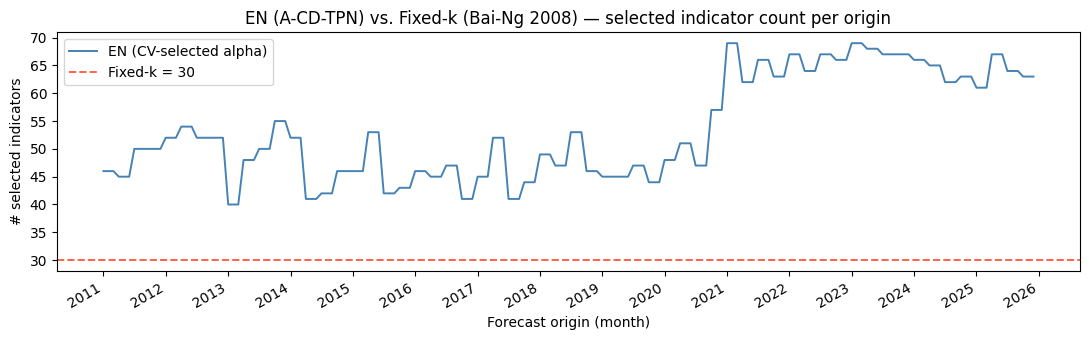

Jaccard similarity (EN vs. fixed-k) across 180 origins:
count    180.000
mean       0.376
std        0.045
min        0.293
25%        0.342
50%        0.366
75%        0.407
max        0.500
dtype: float64


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
# Compare EN (CV-selected) vs. fixed-k selection counts per origin
if RUN_FIXEDK or FIXEDK_MATRIX_PATH.exists():
    n_en = selection_matrix.sum(axis=1)
    n_fk = fixedk_matrix.reindex(n_en.index).sum(axis=1)
    _x = pd.to_datetime(n_en.index)
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(_x, n_en.values, label='EN (CV-selected alpha)', color='steelblue', lw=1.4)
    ax.axhline(FIXEDK_K, color='tomato', ls='--', lw=1.4, label=f'block-balanced (k=20) = {FIXEDK_K}')
    ax.set_xlabel('Forecast origin (month)')
    ax.set_ylabel('# selected indicators')
    ax.set_title('EN (A-CD-TPN) vs. block-balanced (k=20) (Bai-Ng 2008) — selected indicator count per origin')
    ax.legend()
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    # Overlap between EN and fixed-k per origin (Jaccard)
    sel_en = selection_matrix.astype(bool)
    sel_fk = fixedk_matrix.astype(bool)
    intersection = (sel_en & sel_fk).sum(axis=1)
    union = (sel_en | sel_fk).sum(axis=1)
    jaccard = intersection / union.replace(0, np.nan)
    _no = len(selection_matrix)
    print(f'Jaccard similarity (EN vs. fixed-k) across {_no} origins:')
    print(jaccard.describe().round(3))

## 6. Selection Stability Analysis and Economic Interpretation

### Purpose

This section characterises the Elastic Net selection output along three dimensions:
1. **Persistence:** Which predictors are selected most frequently across the 180 forecast origins?
2. **Economic composition:** How are selections distributed across macroeconomic categories (e.g., production, surveys, trade)?
3. **Temporal evolution:** How does the active set size change as the training window expands?

These diagnostics support the thesis narrative by identifying a "core set" of robust indicators and revealing structural changes in predictor relevance over time.

### Key Outputs and Interpretation

#### 1. Selection Frequency Distribution

**Construction:** For each of the 585 series, compute the proportion of the 180 origins at which it was selected (1 in `selection_matrix`).

**Expected pattern:**  
- **Right-skewed distribution:** Most series are rarely selected; a small subset appears in >50% of origins.
- **Long tail:** Many series have zero or near-zero frequency (eliminated by coverage filter or regularisation).

**Economic interpretation:** High-frequency series are persistently judged informative for German GDP growth conditional on:
- The expanding-window training design  
- The Elastic Net penalty structure  
- The presence of other predictors in the panel  

**Important caveat:** Selection frequency reflects *algorithmic preference* given the full predictor set, not standalone GDP correlation. In the presence of multicollinearity, one series may substitute for several correlated alternatives (e.g., one of multiple industrial production indices is selected while others are not, despite similar GDP correlations).

#### 2. Top Series by Economic Category

**Construction:** Rank series by selection frequency and display the top-*N* (default: 20 or 30) along with their category labels (from `DATA_DICT_ENRICHED_CSV`).

**Use cases:**
- **Thesis main text:** Cite the top 5–10 series to illustrate the selected set's economic content. Example: "The most persistent indicators include industrial new orders (category: Production), IFO business climate (category: Surveys), and export expectations (category: Trade), consistent with established leading-indicator research (Abberger et al., 2014)."

- **Methodological discussion:** Compare category distributions between Elastic Net and other methods (PLS, fixed-*k*) in `04_pls_selection_and_stability.ipynb` to assess whether different selectors emphasise hard data vs. soft data.

- **Robustness argument:** A balanced category distribution (production, surveys, trade, prices, employment) supports the claim that the DFM input captures multiple dimensions of the German business cycle, rather than over-relying on one sector.

**Caveat:** Category labels are descriptive (assigned during data preparation), not exhaustive. "Unknown" or missing categories may appear for series lacking metadata.

#### 3. Selection Count Over Time

**Construction:** Sum the binary selection indicator across series at each origin to obtain the active set size *k_t* for each of the 180 months.

**Temporal patterns to examine:**
- **Expanding-window growth:** Does *k_t* increase as the training sample grows (more stable coefficient identification)?
- **Structural breaks:** Do selection counts drop sharply during crisis periods (2008–2009 recession, 2020 pandemic) when predictor correlations destabilise?
- **Quarterly steps:** The cache logic should produce piecewise-constant counts within quarters (adjacent months in the same quarter have identical selections).

**Economic interpretation:**  
- **Larger *k*:** More predictors pass the regularisation threshold, possibly reflecting higher GDP volatility requiring broader information.
- **Smaller *k*:** Tighter regularisation, possibly due to smaller training samples early in the window or periods of stable low-volatility GDP growth where few predictors are needed.

**Comparison to fixed-*k*:** Plotting EN count alongside the Fixed-*k* = 30 baseline reveals whether CV-tuning systematically selects more or fewer predictors.

#### 4. Selection Heatmap (Optional, Top-30 Series)

**Construction:** Subset `selection_matrix` to the 30 most frequent series (rows: origins, columns: series). Display as a binary heatmap where dark cells indicate selection.

**Visual insights:**
- **Persistent blocks:** Horizontal bands of dark cells indicate series selected across many origins.
- **Dropout episodes:** Gaps in otherwise persistent series may align with structural breaks or data revisions.
- **Turnover:** If most series appear for only a few scattered origins, the selected set is highly volatile (concerning for DFM stability).

**Use in thesis:** Include the heatmap in an appendix with a caption: "Temporal selection patterns for the 30 most frequently chosen predictors. Persistent horizontal bands indicate algorithm-robust indicators suitable for the core DFM input."

### Relationship to Part II (DFM Nowcasting)

**Core set identification:** Series with selection frequency >50% (appearing in >90 of 180 origins) form the persistent backbone of the `en_only` matrix — the input set of the headline DFM-EN specification in `06_dfm_nowcasting.ipynb` (the ≥3/4 cross-method consensus set built in `05_build_model_inputs.ipynb` serves XGBoost hyperparameter tuning, not the headline DFM).

**Sensitivity analysis:** Series with moderate frequency (30–50%) are included in robustness checks or alternative input sets built in `05_build_model_inputs.ipynb`.

**Exclusion rule:** Series with frequency <10% (selected in <18 origins) are likely noise-dominated or redundant and can be safely omitted from DFM inputs without information loss.

**References:**
- Abberger, K., Birnbrich, M., & Seiler, C. (2014). The German business cycle and the Ifo Business Climate Index. *Journal of Business Cycle Research*, 10(2), 179–195.


In [8]:
from german_gdp_nowcasting.selection.selection_postprocessing import compute_selection_stability

data_dict = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV)
stability = compute_selection_stability(selection_matrix, data_dict=data_dict)
print(f'Series ever selected (selection_freq > 0)  : {(stability.selection_freq > 0).sum()} / {len(stability)}')
print(f'Series always selected (selection_freq = 1): {(stability.selection_freq == 1).sum()}')
print()
print('Top 30 most persistently selected indicators:')
cols_show = ['selection_freq', 'n_selected']
if 'category' in stability.columns:
    cols_show.append('category')
print(stability.head(30)[cols_show].to_string())

Series ever selected (selection_freq > 0)  : 177 / 585
Series always selected (selection_freq = 1): 12

Top 30 most persistently selected indicators:
                     selection_freq  n_selected    category
detrad4770                 1.000000         180    Turnover
detrad1880                 1.000000         180    Turnover
detrad1929                 1.000000         180    Turnover
detrad3518                 1.000000         180    Turnover
detrad1953                 1.000000         180    Turnover
deprod0191                 1.000000         180  Production
detrad1954                 1.000000         180    Turnover
detrad1879                 1.000000         180    Turnover
detrad1878                 1.000000         180    Turnover
detrad0692                 1.000000         180       Trade
detrad3364                 1.000000         180    Turnover
detrad3365                 1.000000         180    Turnover
serv_de_74_cof_bs_m        0.916667         165     Surveys
detrad1928

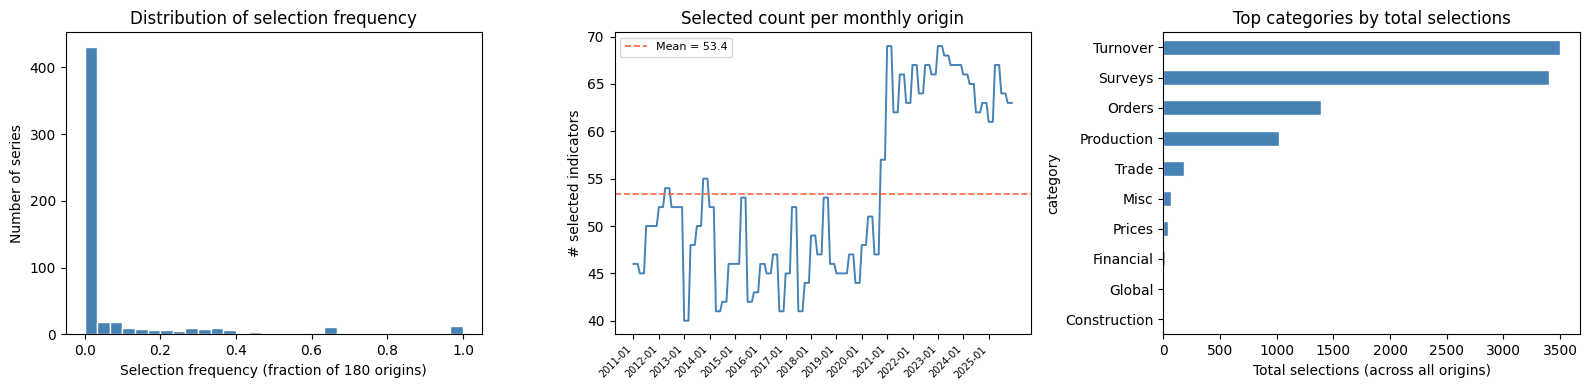

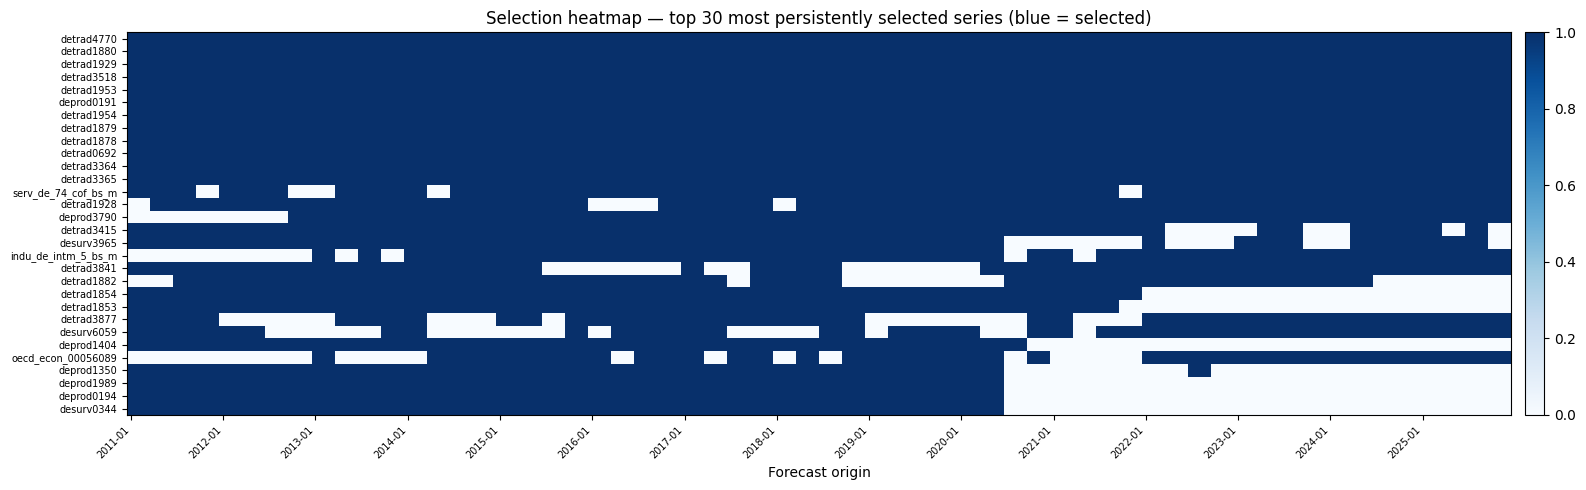

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
_n_origins = len(selection_matrix)
# — Panel 1: selection frequency distribution
ax = axes[0]
ax.hist(stability['selection_freq'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel(f'Selection frequency (fraction of {_n_origins} origins)')
ax.set_ylabel('Number of series')
ax.set_title('Distribution of selection frequency')
# — Panel 2: selected count per origin over time
ax = axes[1]
n_sel = selection_matrix.sum(axis=1)
ax.plot(range(len(n_sel)), n_sel.values, color='steelblue', lw=1.4)
ax.axhline(n_sel.mean(), color='tomato', ls='--', lw=1.2, label=f'Mean = {n_sel.mean():.1f}')
# Mark quarter boundaries (every 3rd origin)
q_ticks = list(range(0, len(n_sel), 3))
ax.set_xticks(q_ticks[::4])
ax.set_xticklabels(
    [selection_matrix.index[i] for i in q_ticks[::4]],
    rotation=45, ha='right', fontsize=7
)
ax.set_ylabel('# selected indicators')
ax.set_title('Selected count per monthly origin')
ax.legend(fontsize=8)
# — Panel 3: top-10 categories by total selection count
ax = axes[2]
if 'category' in stability.columns:
    cat_counts = stability.groupby('category')['n_selected'].sum().sort_values(ascending=True).tail(10)
    cat_counts.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Total selections (across all origins)')
    ax.set_title('Top categories by total selections')
else:
    ax.text(0.5, 0.5, 'Category labels not available', ha='center', va='center',
            transform=ax.transAxes)
plt.tight_layout()
plt.show()
# Top-30 heatmap: origins × persistently selected series
top30_ids = stability.head(30).index.tolist()
heatmap_data = selection_matrix[top30_ids].astype(float)
fig2, ax2 = plt.subplots(figsize=(16, 5))
im = ax2.imshow(heatmap_data.T, aspect='auto', cmap='Blues', vmin=0, vmax=1, interpolation='none')
ax2.set_yticks(range(len(top30_ids)))
ax2.set_yticklabels(top30_ids, fontsize=7)
# x-axis: show every 12th origin (annual)
xtick_pos = list(range(0, len(selection_matrix), 12))
ax2.set_xticks(xtick_pos)
ax2.set_xticklabels(
    [selection_matrix.index[i] for i in xtick_pos],
    rotation=45, ha='right', fontsize=7
)
ax2.set_xlabel('Forecast origin')
ax2.set_title('Selection heatmap — top 30 most persistently selected series (blue = selected)')
plt.colorbar(im, ax=ax2, fraction=0.02, pad=0.01)
plt.tight_layout()
plt.show()